# Employee Attrition Prediction using Logistic Regression

**Author:** Mahnoor  
**Date:** July 2026   
**Project Type:** Binary Classification

## Project Overview

Employee attrition is an important challenge for organizations because losing experienced employees can lead to increased recruitment costs, reduced productivity, and loss of organizational knowledge.

The goal of this project is to build a Logistic Regression model that predicts whether an employee is likely to leave the company based on demographic information, work history, and job-related factors.

This notebook follows the complete machine learning workflow, including:
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature encoding and scaling
- Model training
- Model evaluation
- Discussion of results

## Import Libraries

This project uses Python libraries for data manipulation, visualization, preprocessing, model training, and evaluation.

- **Pandas** and **NumPy** are used for data handling.
- **Matplotlib** is used to create visualizations during exploratory data analysis.
- **Scikit-learn** provides the tools for preprocessing the data, training the Logistic Regression model, and evaluating its performance.

In [212]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix

## Load Dataset

The employee attrition dataset is loaded into a Pandas DataFrame. It contains employee demographic information, job-related features, and the target variable (`attrition`), which indicates whether an employee left the company.

In [213]:
df = pd.read_csv("../data/employee_attrition_dataset_10000.csv")

## Data Cleaning and Preprocessing

Before performing analysis, the dataset is cleaned and standardized.

The following preprocessing steps are carried out:
- Remove the `Employee_ID` column since it is only an identifier and does not contribute to prediction.
- Rename the columns using lowercase names for consistency and easier access.
- Convert the binary categorical variables (`overtime` and `attrition`) into numerical values (`0` and `1`) so they can be used by machine learning models.

In [214]:
df = df.drop(columns = "Employee_ID")
df = df.rename(columns = {"Age" : "age", "Gender" : "gender", "Marital_Status" : "marital_status",
                          "Department" : "department", "Job_Role" : "job_role", "Job_Level" : "job_level",
                          "Monthly_Income" : "monthly_income", "Hourly_Rate" : "hourly_rate",
                          "Years_at_Company" : "years_at_company", "Years_in_Current_Role" : "years_in_current_role",
                          "Years_Since_Last_Promotion" : "years_since_last_promotion", "Work_Life_Balance" : "work_life_balance",
                          "Job_Satisfaction" : "job_satisfaction", "Performance_Rating" : "performance_rating",
                          "Training_Hours_Last_Year" : "training_hours_last_year", "Overtime" : "overtime",
                          "Project_Count" : "project_count", "Average_Hours_Worked_Per_Week" : "average_hours_worked_per_week",
                          "Absenteeism" : "absenteeism", "Work_Environment_Satisfaction" : "work_environment_satisfaction",
                          "Relationship_with_Manager" : "relationship_with_manager", "Job_Involvement" : "job_involvement",
                          "Distance_From_Home" : "distance_from_home", "Number_of_Companies_Worked" : "number_of_companies_worked",
                          "Attrition" : "attrition"})
df["overtime"] = df["overtime"].replace({"Yes" : 1, "No" : 0})
df["overtime"] = df["overtime"].astype(int)
df["attrition"] = df["attrition"].replace({"Yes" : 1, "No" : 0})
df["attrition"] = df["attrition"].astype(int)

## Exploratory Data Analysis

### Employee Attrition Distribution

The first step in the exploratory analysis is to examine the distribution of the target variable (`attrition`). Understanding whether the classes are balanced is important because class imbalance can influence the performance of classification models.

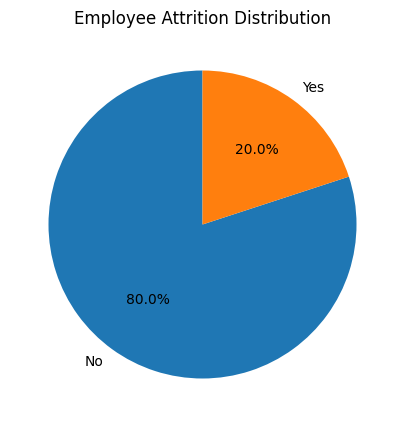

In [215]:
attrition = df.groupby("attrition")["attrition"].count()

plt.figure(figsize=(5,5))
plt.pie(
    attrition,
    labels=["No", "Yes"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Employee Attrition Distribution")
plt.show()


### Observation

Approximately **80%** of employees remained at the company, while **20%** left. This indicates that the dataset is moderately imbalanced, which may cause the model to favor predicting the majority class during training.

### Employee Distribution Across Departments

This visualization shows how employees are distributed across different departments. Understanding the composition of the workforce helps provide context for later analyses and can reveal whether certain departments have noticeably more employees than others.

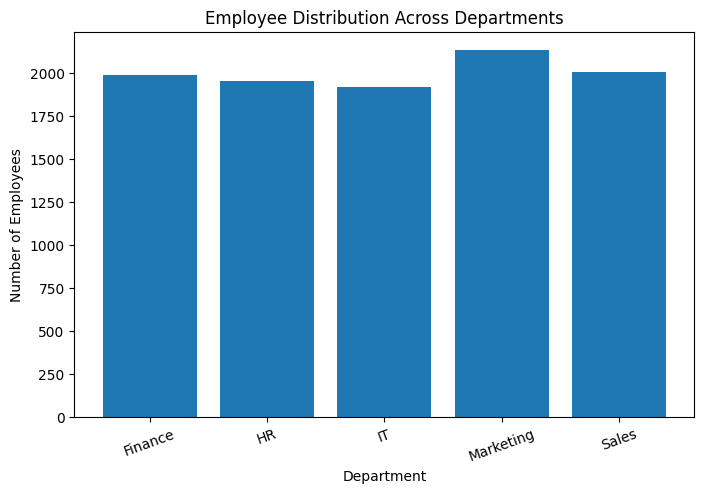

In [216]:
values = df.groupby("department")["department"].count().values
departments = df.groupby("department")["department"].count().index

plt.figure(figsize=(8,5))
plt.bar(departments, values)
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.title("Employee Distribution Across Departments")
plt.xticks(rotation=20)
plt.show()



### Observation

The number of employees is relatively evenly distributed across departments, with no department overwhelmingly larger than the others.

### Employee Distribution by Overtime

This visualization shows the number of employees who work overtime compared to those who do not. Examining this feature helps determine whether overtime is common within the organization and provides context for later investigating its relationship with employee attrition.

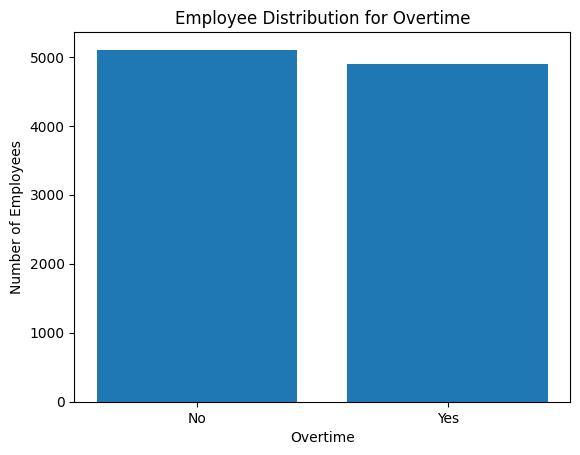

In [217]:
values = df.groupby("overtime")["overtime"].count().values
overtime = df.groupby("overtime")["overtime"].count().index

plt.bar(overtime, values)
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.title("Employee Distribution for Overtime")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

### Observation

The distribution of employees who work overtime and those who do not appears relatively balanced, with no large difference between the two groups.

### Employee Attrition by Department

After examining the overall employee distribution, the next step is to investigate how attrition varies across departments. This helps identify whether employees leaving the company are concentrated in specific departments.

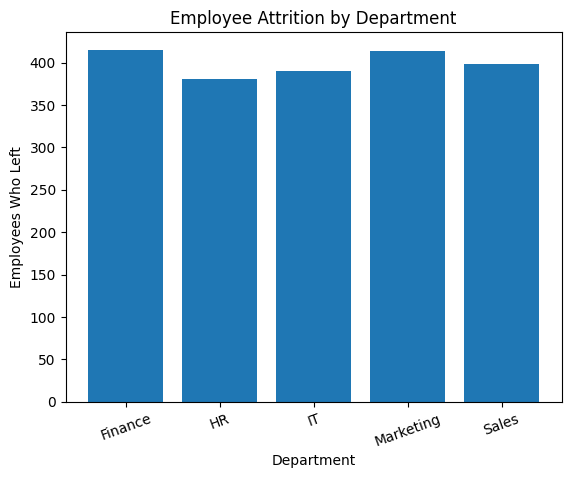

In [218]:
department_counts = yes_attrition.groupby("department")["department"].count()

values = department_counts.values
departments = department_counts.index

plt.bar(departments, values)
plt.xlabel("Department")
plt.ylabel("Employees Who Left")
plt.title("Employee Attrition by Department")
plt.xticks(rotation=20)
plt.show()


### Observation

Employee attrition is observed across all departments, with no single department showing an overwhelmingly higher number of employees leaving.

### Employee Attrition Rate by Overtime

Rather than comparing the number of employees who left, this visualization compares the **attrition rate** for employees who worked overtime and those who did not. Using percentages provides a fair comparison between the two groups, even if they contain different numbers of employees.

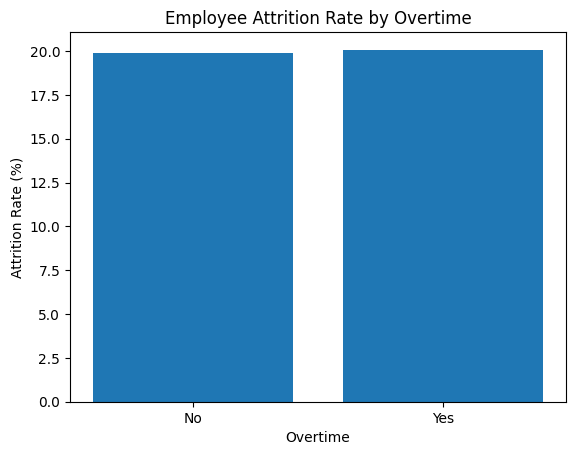

In [219]:
overtime_counts = yes_attrition.groupby("overtime")["overtime"].count()
total_overtime = df.groupby("overtime")["overtime"].count()

values_overtime = overtime_counts.values
values_total = total_overtime.values
rate = (values_overtime / values_total) * 100
overtimes = overtime_counts.index

plt.bar(overtimes, rate)
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.title("Employee Attrition Rate by Overtime")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()


### Observation

The attrition rate is approximately the same for employees who worked overtime and those who did not. Based on this dataset, overtime does not appear to have a strong relationship with employee attrition.

### Comparing Numerical Features

To better understand the dataset, the average values of selected numerical features are compared for employees who stayed and employees who left. Large differences may indicate that a feature is useful for predicting attrition.

In [228]:
print(df.groupby("attrition")["monthly_income"].mean())
print(df.groupby("attrition")["years_at_company"].mean())

attrition
0    11436.385605
1    11438.043565
Name: monthly_income, dtype: float64
attrition
0    14.924903
1    14.981472
Name: years_at_company, dtype: float64


### Observation

The average monthly income and average years at the company are nearly identical for employees who stayed and those who left. These features do not appear to provide strong predictive information for employee attrition in this dataset.

## Prepare Features and Target

The dataset is divided into:

- **Features (`X`)**: All employee attributes used to make predictions.
- **Target (`y`)**: The `attrition` column, which indicates whether an employee left the company (`1`) or stayed (`0`).

In [222]:
X = df.drop(columns = "attrition")
y = df["attrition"]

## Train-Test Split and Feature Preprocessing

The dataset is divided into training and testing sets using an 80-20 split. The training set is used to train the model, while the testing set is reserved for evaluating its performance on unseen data.

Since the dataset contains both numerical and categorical features, different preprocessing techniques are applied:

- **Categorical features** are transformed using **One-Hot Encoding**.
- **Numerical features** are standardized using **StandardScaler** so they are on a similar scale.

A `ColumnTransformer` is used to apply the appropriate preprocessing to each feature type.

In [223]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
categorical = ["gender", "marital_status", "department", "job_role"]
numerical = ["age", "job_level", "monthly_income", "hourly_rate", "years_at_company", "years_in_current_role",
             "years_since_last_promotion", "work_life_balance", "job_satisfaction", "performance_rating",
             "training_hours_last_year", "overtime", "project_count", "average_hours_worked_per_week",
             "absenteeism", "work_environment_satisfaction", "relationship_with_manager", "job_involvement",
             "distance_from_home", "number_of_companies_worked"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numerical)
    ],
    remainder="passthrough"
)
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Model Development

A Logistic Regression classifier is used as the baseline model for this project.

Since the dataset contains more employees who stayed than employees who left, `class_weight="balanced"` is used to reduce the impact of class imbalance during training. This allows the model to place greater emphasis on correctly identifying the minority class.

In [224]:
model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

## Model Evaluation

The trained model is evaluated on the testing set to measure how well it generalizes to unseen data.

Two evaluation metrics are used:

- **Accuracy** measures the overall percentage of correct predictions.
- **Confusion Matrix** provides a more detailed breakdown of the model's predictions by comparing the predicted classes with the actual classes.

In [226]:
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.3f}")
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.502

Confusion Matrix:
[[803 789]
 [207 201]]


### Results

The Logistic Regression model achieved an accuracy of approximately **50%** on the testing set.

Although using `class_weight="balanced"` encouraged the model to predict both classes, the overall performance remained low. The confusion matrix shows that the model struggled to clearly distinguish between employees who stayed and those who left, resulting in a large number of misclassifications.

### Conclusion

The exploratory data analysis also showed that several features, such as monthly income, years at the company, and overtime, exhibited little difference between the two classes. This suggests that the available features may not provide strong predictive information for employee attrition, or that a more flexible model may be required to capture the underlying relationships.